<a href="https://colab.research.google.com/github/Pranav-Bankar/Machine_Learning/blob/main/Practical_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [ ]:
df = pd.read_csv("Boston.csv")
df

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


In [ ]:
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [ ]:
df.tail()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0
505,0.04741,0.0,11.93,0,0.573,6.030,80.8,2.5050,1,273,21.0,396.90,7.88,11.9


In [ ]:
df.shape

(506, 14)

In [ ]:
df.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,501.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284341,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.705587,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.884000,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208000,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.625000,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [ ]:
df.isnull()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,False,False,False,False,False,False,False,False,False,False,False,False,False,False
502,False,False,False,False,False,False,False,False,False,False,False,False,False,False
503,False,False,False,False,False,False,False,False,False,False,False,False,False,False
504,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
df.isnull().sum()

crim       0
zn         0
indus      0
chas       0
nox        0
rm         5
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

In [ ]:
df.dropna(inplace=True)

In [ ]:
df.isnull().sum()

crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

In [ ]:
X = df.drop(columns=['medv']).values
X = df[['age']].values
y = df['medv'].values

In [ ]:
feature_names = df.drop(columns=['medv']).columns.tolist()
feature_names = ['age']

In [ ]:
display(df.head())

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
print(f"Training data shape: {X_train_scaled.shape}")
print(f"Testing data shape: {X_test_scaled.shape}")

Training data shape: (350, 1)
Testing data shape: (151, 1)


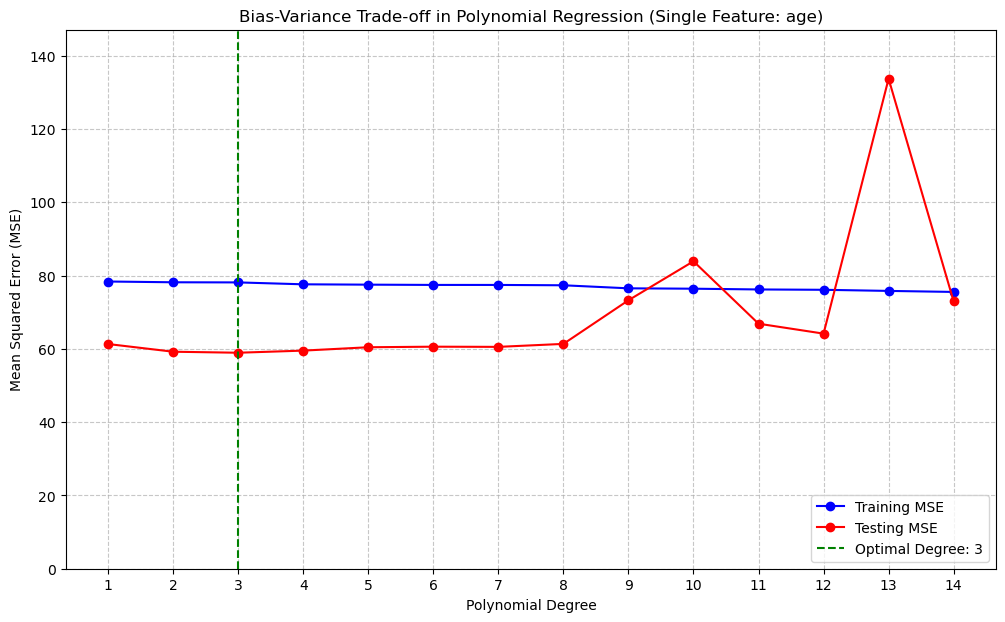

Observation: As the polynomial degree increases, the training error generally decreases (model fits training data)


In [ ]:
degrees = np.arange(1, 15)
train_errors = []
test_errors = []
for degree in degrees:
  poly_features = PolynomialFeatures(degree=degree)
  X_train_poly = poly_features.fit_transform(X_train_scaled)
  X_test_poly = poly_features.transform(X_test_scaled)
  model = LinearRegression()
  model.fit(X_train_poly, y_train)
  y_train_pred = model.predict(X_train_poly)
  y_test_pred = model.predict(X_test_poly)
  train_mse = mean_squared_error(y_train, y_train_pred)
  test_mse = mean_squared_error(y_test, y_test_pred)
  train_errors.append(train_mse)
  test_errors.append(test_mse)
optimal_degree_for_plot = degrees[np.argmin(test_errors)]

plt.figure(figsize=(12, 7))
plt.plot(degrees, train_errors, label='Training MSE', marker='o', linestyle='-', color='blue')
plt.plot(degrees, test_errors, label='Testing MSE', marker='o', linestyle='-', color='red')
plt.title('Bias-Variance Trade-off in Polynomial Regression (All Features)')
plt.axvline(x=optimal_degree_for_plot, color='green', linestyle='--', label=f'Optimal Degree: {optimal_degree_for_plot}')
plt.title('Bias-Variance Trade-off in Polynomial Regression (Single Feature: age)')
plt.xlabel('Polynomial Degree')
plt.ylabel('Mean Squared Error (MSE)')
plt.xticks(degrees)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.ylim(0, max(max(train_errors), max(test_errors)) * 1.1)
plt.show()
print("Observation: As the polynomial degree increases, the training error generally decreases (model fits training data)")

In [ ]:
optimal_degree = degrees[np.argmin(test_errors)]
print(f"Optimal polynomial degree (based on minimum test MSE): {optimal_degree}")

Optimal polynomial degree (based on minimum test MSE): 3


In [ ]:
poly_features_optimal = PolynomialFeatures(degree=optimal_degree)
X_train_poly_optimal = poly_features_optimal.fit_transform(X_train_scaled)
X_test_poly_optimal = poly_features_optimal.transform(X_test_scaled)

In [ ]:
model_optimal = LinearRegression()
model_optimal.fit(X_train_poly_optimal, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
y_test_pred_optimal = model_optimal.predict(X_test_poly_optimal)

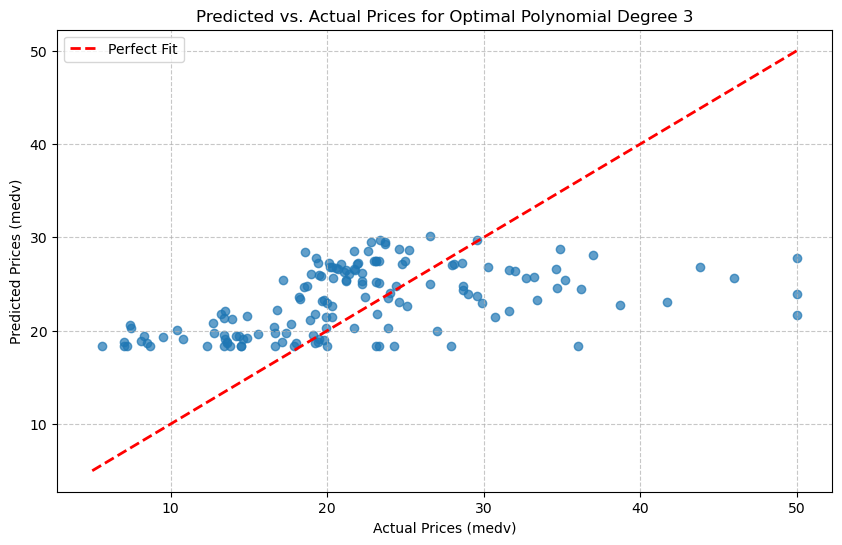

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_test_pred_optimal, alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Fit')
plt.xlabel('Actual Prices (medv)')
plt.ylabel('Predicted Prices (medv)')
plt.title(f'Predicted vs. Actual Prices for Optimal Polynomial Degree {optimal_degree}')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

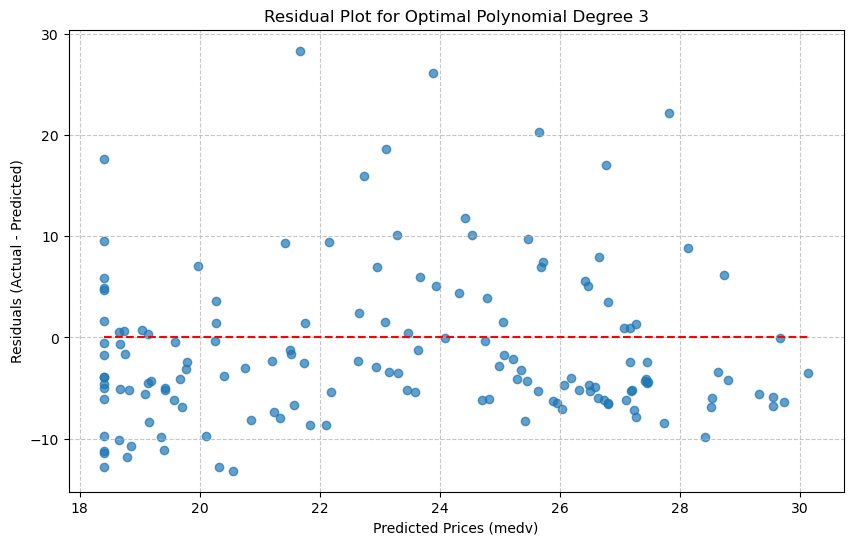

In [ ]:
residuals = y_test - y_test_pred_optimal
plt.figure(figsize=(10, 6))
plt.scatter(y_test_pred_optimal, residuals, alpha=0.7)
plt.hlines(0, y_test_pred_optimal.min(), y_test_pred_optimal.max(), colors='r', linestyles='--')
plt.xlabel('Predicted Prices (medv)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title(f'Residual Plot for Optimal Polynomial Degree {optimal_degree}')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
def plot_performance_for_degree(degree, X_train_scaled, y_train, X_test_scaled, y_test):
 poly_features = PolynomialFeatures(degree=degree)
 X_train_poly = poly_features.fit_transform(X_train_scaled)
 X_test_poly = poly_features.transform(X_test_scaled)
 model = LinearRegression()
 model.fit(X_train_poly, y_train)
 y_test_pred = model.predict(X_test_poly)

 plt.figure(figsize=(10, 6))
 plt.scatter(y_test, y_test_pred, alpha=0.7)
 plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Fit')
 plt.xlabel('Actual Prices (medv)')
 plt.ylabel('Predicted Prices (medv)')
 plt.title(f'Predicted vs. Actual Prices for Degree {degree}')
 plt.grid(True, linestyle='--', alpha=0.7)
 plt.legend()
 plt.show()